# YOLOv11n — Cacao Bean Detection Experiment

**Experiment 1 of 3** (independent, non-comparative in this notebook): `YOLOv11n`, `MobileNet-SSDv3`, `EfficientDet-Lite0`.
This notebook trains and evaluates **only YOLOv11n**. No other model is trained or compared here.

**Dataset:** `Cacao_Bean_Detection_Trial_01_v12-d800-70-20-10_coco.zip` (Roboflow COCO export, 800 images, classes: `Broken`, `Cluster`, `Flat`, `Normal`).

**Fixed experimental protocol (must match the other two experiments):**
| Setting | Value |
|---|---|
| Random seed | 42 |
| Split | 80% train / 10% val / 10% test |
| Input resolution | 640×640 |
| Epochs | 50 |
| Batch size | 16 |
| Confidence threshold | 0.25 |
| IoU threshold | 0.50 |

Run cells top-to-bottom on a **Google Colab GPU runtime** (Runtime → Change runtime type → GPU).


## 1. Environment Verification

Confirms a GPU is attached before doing anything else. Execution stops with a clear error if no GPU is found.

In [ ]:
import sys, platform, subprocess

# torch ships preinstalled on Colab runtimes, so we can check the GPU before installing anything else.
try:
    import torch
except ImportError:
    raise SystemExit("PyTorch is not available in this runtime. Use a standard Google Colab runtime.")

gpu_available = torch.cuda.is_available()
print(f"Python version : {platform.python_version()}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {gpu_available}")

if not gpu_available:
    raise SystemExit(
        "\n\n*** NO GPU DETECTED ***\n"
        "This notebook requires a GPU runtime.\n"
        "Go to: Runtime -> Change runtime type -> Hardware accelerator -> GPU, then re-run.\n"
    )

gpu_name = torch.cuda.get_device_name(0)
cuda_version = torch.version.cuda
print(f"GPU name       : {gpu_name}")
print(f"CUDA version   : {cuda_version}")
print("\nGPU check passed. Continuing.")


Python version : 3.13.15
PyTorch version: 2.11.0+cu128
CUDA available : True
GPU name       : Tesla T4
CUDA version   : 12.8

GPU check passed. Continuing.


## 2. Install Dependencies

In [ ]:
%%capture
!pip install -q "ultralytics>=8.3.0" pycocotools scikit-learn seaborn


In [ ]:
import ultralytics
ultralytics.checks()
print(f"\nUltralytics version: {ultralytics.__version__}")


Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)

Ultralytics version: 8.4.138


## 3. Imports, Global Seed, and Reproducibility Setup

In [ ]:
import os, sys, json, glob, shutil, random, time, zipfile, math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageDraw

from sklearn.model_selection import train_test_split

SEED = 42

def set_global_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_global_seed(SEED)
print(f"Global random seed fixed at {SEED} (python, numpy, torch, PYTHONHASHSEED).")

WORK_DIR = Path("/content/cacao_yolov11n")
WORK_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(WORK_DIR)
print(f"Working directory: {WORK_DIR}")


Global random seed fixed at 42 (python, numpy, torch, PYTHONHASHSEED).
Working directory: /content/cacao_yolov11n


## 4. Dataset Upload

Upload the COCO-format dataset ZIP (e.g. `Cacao_Bean_Detection_Trial_01_v12-d800-70-20-10_coco.zip`).

Optional: if you already generated a `dataset_split_seed42.json` manifest from a **previous run of this notebook** (or from one of the sibling model notebooks), you may upload it as well in the same step to force the exact same train/val/test assignment. If you don't have one, the notebook will create it — and you can then reuse that file in the other two experiment notebooks to guarantee identical splits.

In [ ]:
from google.colab import files

print("Select the dataset ZIP file (and optionally a previously saved dataset_split_seed42.json).")
uploaded = files.upload()

zip_candidates = [f for f in uploaded if f.lower().endswith(".zip")]
json_candidates = [f for f in uploaded if f.lower().endswith(".json")]

if not zip_candidates:
    raise SystemExit("No .zip file was uploaded. Please re-run this cell and upload the COCO dataset ZIP.")

DATASET_ZIP = zip_candidates[0]
EXTERNAL_SPLIT_MANIFEST = json_candidates[0] if json_candidates else None
print(f"Dataset ZIP: {DATASET_ZIP}")
print(f"External split manifest: {EXTERNAL_SPLIT_MANIFEST}")


Select the dataset ZIP file (and optionally a previously saved dataset_split_seed42.json).


Saving Cacao Bean Detection_Trial 01.v5-trial4_2400.coco.zip to Cacao Bean Detection_Trial 01.v5-trial4_2400.coco.zip
Dataset ZIP: Cacao Bean Detection_Trial 01.v5-trial4_2400.coco.zip
External split manifest: None


In [ ]:
RAW_DIR = WORK_DIR / "dataset_raw"
if RAW_DIR.exists():
    shutil.rmtree(RAW_DIR)
RAW_DIR.mkdir(parents=True)

with zipfile.ZipFile(DATASET_ZIP, "r") as zf:
    zf.extractall(RAW_DIR)

print(f"Extracted to: {RAW_DIR}")
for p in sorted(RAW_DIR.rglob("*"))[:20]:
    print(" ", p.relative_to(RAW_DIR))
n_files = sum(1 for _ in RAW_DIR.rglob("*") if _.is_file())
print(f"... ({n_files} files total)")


Extracted to: /content/cacao_yolov11n/dataset_raw
  README.dataset.txt
  README.roboflow.txt
  test
  test/M4_FR_NormFlatBrokClus-18-_jpg.rf.1e619eaa40f06517f8ed04b938370d77.jpg
  test/M4_FR_NormFlatBrokClus-19-_jpg.rf.6bed7f5ace84eb717edca9597ef0c685.jpg
  test/M4_FR_NormFlatBrokClus-2-_jpg.rf.43066e4fd13db17d68e106b0897254e1.jpg
  test/M4_FR_NormFlatBrokClus-22-_jpg.rf.d813239010e600102efb2a9149b76205.jpg
  test/M4_FR_NormFlatBrokClus-39-_jpg.rf.81e2cad8787f668f940ab31f80987b2d.jpg
  test/M4_FR_NormFlatBrokClus-49-_jpg.rf.70698b7810276afc0065fde07a8cba58.jpg
  test/M4_FR_NormFlatBrokClus-55-_jpg.rf.0e79d4c7fa393c1865c9827bee0cf686.jpg
  test/M4_FR_NormFlatBrokClus-56-_jpg.rf.84e645f3d49da7fc0e7a34d2b2f6cac4.jpg
  test/M4_FR_NormFlatBrokClus-61-_jpg.rf.054a56de2d6d51b0e40f4a1aa7a7210d.jpg
  test/M4_FR_NormFlatBrokClus-65-_jpg.rf.c6e5a18ade94a88809b953eba0f2632b.jpg
  test/M4_FR_NormFlatBrokClus-7-_jpg.rf.08ee969d056dd9740eb2afe072144353.jpg
  test/M4_FR_NormFlatBrokClus-70-_jpg.rf.3f1

## 5. Locate and Validate COCO Annotations

Automatically discovers every COCO JSON file in the extracted archive (regardless of whether the dataset is flat or already pre-split into `train/valid/test` folders), pairs each one with the image directory it describes, and verifies every annotated image actually exists on disk.

In [ ]:
def find_coco_json_files(root: Path):
    # Find every JSON file under root that looks like a COCO annotation file.
    found = []
    for jp in root.rglob("*.json"):
        try:
            with open(jp, "r") as f:
                d = json.load(f)
        except Exception:
            continue
        if isinstance(d, dict) and {"images", "annotations", "categories"} <= set(d.keys()):
            found.append(jp)
    return found

coco_json_files = find_coco_json_files(RAW_DIR)
if not coco_json_files:
    raise SystemExit("No COCO-format annotation JSON file was found inside the ZIP.")

print(f"Found {len(coco_json_files)} COCO annotation file(s):")
for jp in coco_json_files:
    print(" -", jp.relative_to(RAW_DIR))


Found 3 COCO annotation file(s):
 - valid/_annotations.coco.json
 - test/_annotations.coco.json
 - train/_annotations.coco.json


In [ ]:
# Load every COCO file, keep track of which folder (original split) it came from,
# and verify categories are consistent across all files.
loaded_splits = []  # list of dicts: {name, dir, images(dict id->rec), annotations(id->list), categories}
reference_categories = None

for jp in coco_json_files:
    with open(jp, "r") as f:
        d = json.load(f)
    split_name = jp.parent.name.lower()
    split_name = {"valid": "val", "validation": "val"}.get(split_name, split_name)

    cats = sorted(d["categories"], key=lambda c: c["id"])
    if reference_categories is None:
        reference_categories = cats
    else:
        if [c["id"] for c in cats] != [c["id"] for c in reference_categories] or \
           [c["name"] for c in cats] != [c["name"] for c in reference_categories]:
            print(f"WARNING: category set in {jp} differs from the first file encountered.")

    images_by_id = {im["id"]: im for im in d["images"]}
    anns_by_image = defaultdict(list)
    for a in d["annotations"]:
        anns_by_image[a["image_id"]].append(a)

    loaded_splits.append({
        "name": split_name,
        "dir": jp.parent,
        "images": images_by_id,
        "anns": anns_by_image,
        "n_images": len(images_by_id),
        "n_anns": len(d["annotations"]),
    })

print("Categories (from COCO file):")
for c in reference_categories:
    print(f"  id={c['id']:>2}  name={c['name']!r}  supercategory={c.get('supercategory')}")

for s in loaded_splits:
    print(f"\nSplit source '{s['name']}' ({s['dir'].relative_to(RAW_DIR)}): "
          f"{s['n_images']} images, {s['n_anns']} annotations")


Categories (from COCO file):
  id= 0  name='Bean'  supercategory=none
  id= 1  name='Broken'  supercategory=Bean
  id= 2  name='Cluster'  supercategory=Bean
  id= 3  name='Flat'  supercategory=Bean
  id= 4  name='Normal'  supercategory=Bean

Split source 'val' (valid): 200 images, 314 annotations

Split source 'test' (test): 100 images, 182 annotations

Split source 'train' (train): 2100 images, 3315 annotations


In [ ]:
# Verify every referenced image file actually exists, and collect one unified pool of records.
# Each record = one image with its (possibly empty) list of annotations.
pool = []          # list of dicts: file_path, file_name, width, height, anns, orig_split
missing = []
seen_filenames = set()
dup_filenames = []

for s in loaded_splits:
    for img_id, im in s["images"].items():
        fp = s["dir"] / im["file_name"]
        if not fp.exists():
            missing.append(str(fp))
            continue
        if im["file_name"] in seen_filenames:
            dup_filenames.append(im["file_name"])
        seen_filenames.add(im["file_name"])
        pool.append({
            "file_path": fp,
            "file_name": im["file_name"],
            "width": im["width"],
            "height": im["height"],
            "anns": s["anns"].get(img_id, []),
            "orig_split": s["name"],
        })

print(f"Total image records collected : {len(pool)}")
print(f"Missing image files           : {len(missing)}")
print(f"Duplicate file names          : {len(dup_filenames)}")
if missing:
    print("First few missing files:", missing[:5])
if dup_filenames:
    print("First few duplicate names (must be resolved before continuing):", dup_filenames[:5])

assert len(missing) == 0, "Some annotated images are missing from disk. Aborting."
assert len(dup_filenames) == 0, "Duplicate filenames across source folders would collide when merged. Aborting."
print("\nAll images and annotations correspond correctly.")


Total image records collected : 2400
Missing image files           : 0
Duplicate file names          : 0

All images and annotations correspond correctly.


## 6. Dataset Statistics

Category ids actually used in annotations: [1, 2, 3, 4]
   1 -> Broken
   2 -> Cluster
   3 -> Flat
   4 -> Normal
Category id(s) present in metadata but never used as a label: [0] (['Bean']) -- excluded from the YOLO class list.

Total images     : 2400
Total bounding boxes: 3811
Boxes-per-image distribution: {1: 1929, 2: 1, 4: 470}
Image size range : width [640, 640], height [640, 640]


,class_id,class_name,box_count,percent
0,1,Broken,951,24.95
1,2,Cluster,965,25.32
2,3,Flat,949,24.90
3,4,Normal,946,24.82


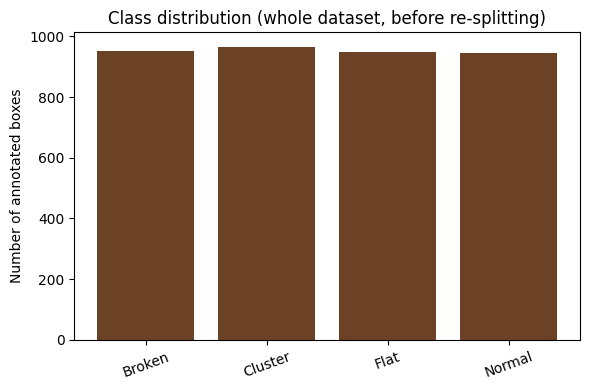

In [ ]:
cat_id_to_name = {c["id"]: c["name"] for c in reference_categories}
# 'Bean' (id 0) is a Roboflow hierarchical supercategory placeholder and is never used
# as an actual annotation label in this export -- confirm that automatically rather than assuming it.
used_cat_ids = sorted({a["category_id"] for r in pool for a in r["anns"]})
print("Category ids actually used in annotations:", used_cat_ids)
for cid in used_cat_ids:
    print(f"   {cid} -> {cat_id_to_name[cid]}")
unused = [c["id"] for c in reference_categories if c["id"] not in used_cat_ids]
if unused:
    print(f"Category id(s) present in metadata but never used as a label: {unused} "
          f"({[cat_id_to_name[i] for i in unused]}) -- excluded from the YOLO class list.")

n_images = len(pool)
n_boxes = sum(len(r["anns"]) for r in pool)
boxes_per_image = Counter(len(r["anns"]) for r in pool)
class_counts = Counter(a["category_id"] for r in pool for a in r["anns"])
widths = [r["width"] for r in pool]
heights = [r["height"] for r in pool]

print(f"\nTotal images     : {n_images}")
print(f"Total bounding boxes: {n_boxes}")
print(f"Boxes-per-image distribution: {dict(sorted(boxes_per_image.items()))}")
print(f"Image size range : width [{min(widths)}, {max(widths)}], height [{min(heights)}, {max(heights)}]")

stats_df = pd.DataFrame([
    {"class_id": cid, "class_name": cat_id_to_name[cid], "box_count": class_counts.get(cid, 0)}
    for cid in used_cat_ids
])
stats_df["percent"] = (100 * stats_df["box_count"] / stats_df["box_count"].sum()).round(2)
display(stats_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(stats_df["class_name"], stats_df["box_count"], color="#6b4226")
ax.set_title("Class distribution (whole dataset, before re-splitting)")
ax.set_ylabel("Number of annotated boxes")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 7. Dataset Split (80% / 10% / 10%, seed 42)

The uploaded export is pre-split (its filename indicates a 70/20/10 split), which does **not** satisfy the required 80/10/10 protocol. Per the requirements, all images from every source folder are therefore pooled together and **re-split reproducibly with seed 42** into 80% train / 10% val / 10% test, stratified by class where possible so the split is class-balanced.

If a `dataset_split_seed42.json` manifest was uploaded above, it is used directly instead, guaranteeing an identical split to whichever notebook produced it (needed so all three model experiments train/evaluate on the exact same images).

In [ ]:
def dominant_label(record):
    # Stratification key: the (single, in this dataset) or most frequent class in the image.
    if not record["anns"]:
        return -1  # background-only image
    counts = Counter(a["category_id"] for a in record["anns"])
    return counts.most_common(1)[0][0]

manifest_path = WORK_DIR / "dataset_split_seed42.json"

if EXTERNAL_SPLIT_MANIFEST is not None:
    with open(EXTERNAL_SPLIT_MANIFEST, "r") as f:
        manifest = json.load(f)
    assign = manifest["assignments"]  # file_name -> split
    print(f"Loaded external split manifest '{EXTERNAL_SPLIT_MANIFEST}' "
          f"(seed={manifest.get('seed')}, created_by={manifest.get('source_notebook')}).")
    for r in pool:
        if r["file_name"] not in assign:
            raise SystemExit(f"File {r['file_name']} is not present in the uploaded split manifest.")
        r["split"] = assign[r["file_name"]]
else:
    file_names = [r["file_name"] for r in pool]
    labels = [dominant_label(r) for r in pool]

    # Guard against classes too small to stratify at this ratio; fall back to unstratified split if needed.
    label_counts = Counter(labels)
    can_stratify = all(c >= 2 for c in label_counts.values())

    idx = list(range(len(pool)))
    strat = labels if can_stratify else None
    train_idx, temp_idx = train_test_split(idx, test_size=0.20, random_state=SEED, stratify=strat)
    strat2 = [labels[i] for i in temp_idx] if can_stratify else None
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=strat2)

    split_of_idx = {}
    for i in train_idx: split_of_idx[i] = "train"
    for i in val_idx:   split_of_idx[i] = "val"
    for i in test_idx:  split_of_idx[i] = "test"
    for i, r in enumerate(pool):
        r["split"] = split_of_idx[i]

    assign = {r["file_name"]: r["split"] for r in pool}
    manifest = {
        "seed": SEED,
        "ratios": {"train": 0.8, "val": 0.1, "test": 0.1},
        "stratified": can_stratify,
        "source_notebook": "01_YOLOv11n_Experiment.ipynb",
        "n_images": len(pool),
        "assignments": assign,
    }
    with open(manifest_path, "w") as f:
        json.dump(manifest, f, indent=2)
    print(f"New reproducible split created and saved to: {manifest_path}")
    print("Download this file and re-upload it in the MobileNet-SSDv3 and EfficientDet-Lite0 "
          "notebooks (alongside the same dataset ZIP) to guarantee an identical split across all three experiments.")

split_counts = Counter(r["split"] for r in pool)
total = sum(split_counts.values())
print("\nFinal split sizes:")
for s in ["train", "val", "test"]:
    n = split_counts.get(s, 0)
    print(f"  {s:5s}: {n:4d} images ({100*n/total:.1f}%)")

# Data-leakage check: every image belongs to exactly one split.
fname_to_splits = defaultdict(set)
for r in pool:
    fname_to_splits[r["file_name"]].add(r["split"])
leaks = [fn for fn, s in fname_to_splits.items() if len(s) > 1]
assert len(leaks) == 0, f"Data leakage detected for files: {leaks}"
print("\nNo data leakage between splits: confirmed (each image belongs to exactly one split).")


New reproducible split created and saved to: /content/cacao_yolov11n/dataset_split_seed42.json
Download this file and re-upload it in the MobileNet-SSDv3 and EfficientDet-Lite0 notebooks (alongside the same dataset ZIP) to guarantee an identical split across all three experiments.

Final split sizes:
  train: 1920 images (80.0%)
  val  :  240 images (10.0%)
  test :  240 images (10.0%)

No data leakage between splits: confirmed (each image belongs to exactly one split).


## 8. Convert COCO Annotations to YOLO Format

Builds a YOLOv11-ready directory (`images/`, `labels/`) from the 80/10/10 split above. Bounding boxes are converted from COCO `[x_min, y_min, w, h]` (absolute pixels) to YOLO `[class, x_center, y_center, w, h]` (normalized 0-1). Original image files are **copied**, never modified or resized on disk — the 640×640 input resolution is applied only at load time by YOLO's dataloader/`imgsz` argument.

In [ ]:
# Build a contiguous 0-indexed class map from the category ids actually used, in ascending id order.
yolo_classes = [cat_id_to_name[cid] for cid in used_cat_ids]
coco_id_to_yolo_id = {cid: i for i, cid in enumerate(used_cat_ids)}
print("YOLO class map (index -> name):")
for i, name in enumerate(yolo_classes):
    print(f"  {i}: {name}   (original COCO category_id={used_cat_ids[i]})")

YOLO_DIR = WORK_DIR / "yolo_dataset"
if YOLO_DIR.exists():
    shutil.rmtree(YOLO_DIR)
for split in ["train", "val", "test"]:
    (YOLO_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

for r in pool:
    split = r["split"]
    dst_img = YOLO_DIR / "images" / split / r["file_name"]
    shutil.copy2(r["file_path"], dst_img)

    # Use actual on-disk image size for normalization (guards against any mismatch with the JSON metadata).
    with Image.open(dst_img) as im:
        real_w, real_h = im.size
    if (real_w, real_h) != (r["width"], r["height"]):
        print(f"NOTE: {r['file_name']} JSON size {(r['width'], r['height'])} "
              f"!= actual size {(real_w, real_h)}; using actual size for label conversion.")

    lines = []
    for a in r["anns"]:
        x, y, w, h = a["bbox"]
        xc = (x + w / 2) / real_w
        yc = (y + h / 2) / real_h
        wn = w / real_w
        hn = h / real_h
        cls = coco_id_to_yolo_id[a["category_id"]]
        lines.append(f"{cls} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")

    label_path = YOLO_DIR / "labels" / split / (Path(r["file_name"]).stem + ".txt")
    with open(label_path, "w") as f:
        f.write("\n".join(lines))

print("\nConversion complete.")
for split in ["train", "val", "test"]:
    n_img = len(list((YOLO_DIR / "images" / split).glob("*")))
    n_lbl = len(list((YOLO_DIR / "labels" / split).glob("*.txt")))
    print(f"  {split:5s}: {n_img} images, {n_lbl} label files")


YOLO class map (index -> name):
  0: Broken   (original COCO category_id=1)
  1: Cluster   (original COCO category_id=2)
  2: Flat   (original COCO category_id=3)
  3: Normal   (original COCO category_id=4)

Conversion complete.
  train: 1920 images, 1920 label files
  val  : 240 images, 240 label files
  test : 240 images, 240 label files


In [ ]:
data_yaml_path = YOLO_DIR / "data.yaml"
data_yaml = {
    "path": str(YOLO_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(yolo_classes),
    "names": yolo_classes,
}
with open(data_yaml_path, "w") as f:
    for k in ["path", "train", "val", "test"]:
        f.write(f"{k}: {data_yaml[k]}\n")
    f.write(f"nc: {data_yaml['nc']}\n")
    f.write("names: " + json.dumps(data_yaml["names"]) + "\n")

print(f"data.yaml written to {data_yaml_path}:\n")
print(data_yaml_path.read_text())


data.yaml written to /content/cacao_yolov11n/yolo_dataset/data.yaml:

path: /content/cacao_yolov11n/yolo_dataset
train: images/train
val: images/val
test: images/test
nc: 4
names: ["Broken", "Cluster", "Flat", "Normal"]



## 9. Verify Conversion — Sample Images with Boxes

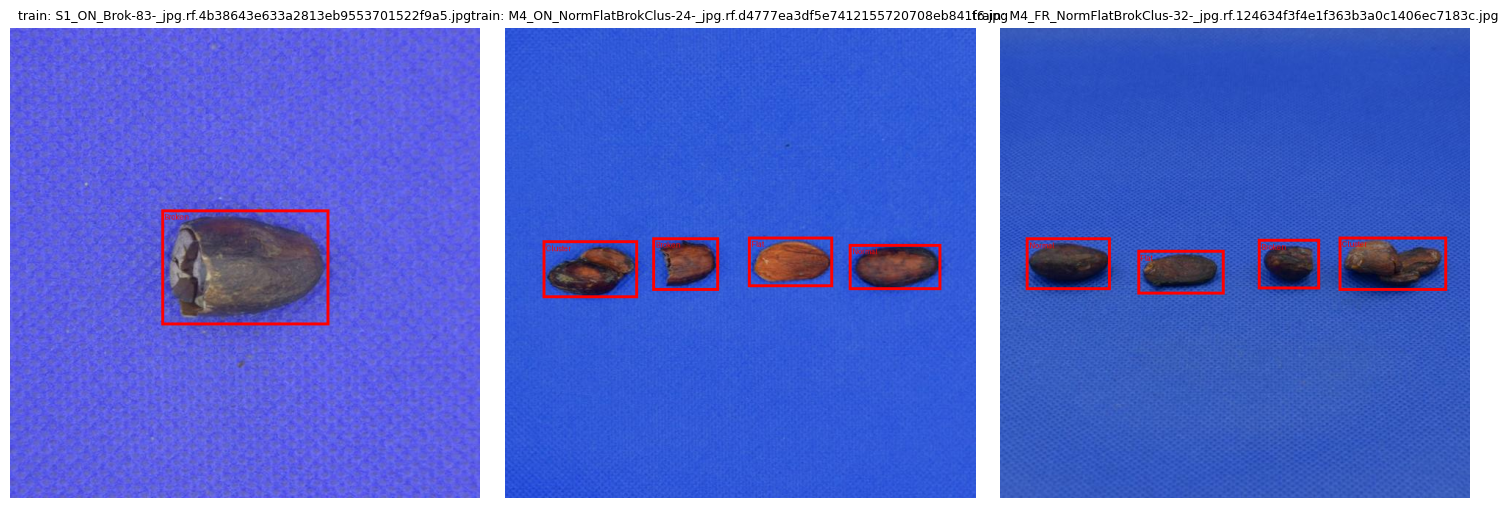

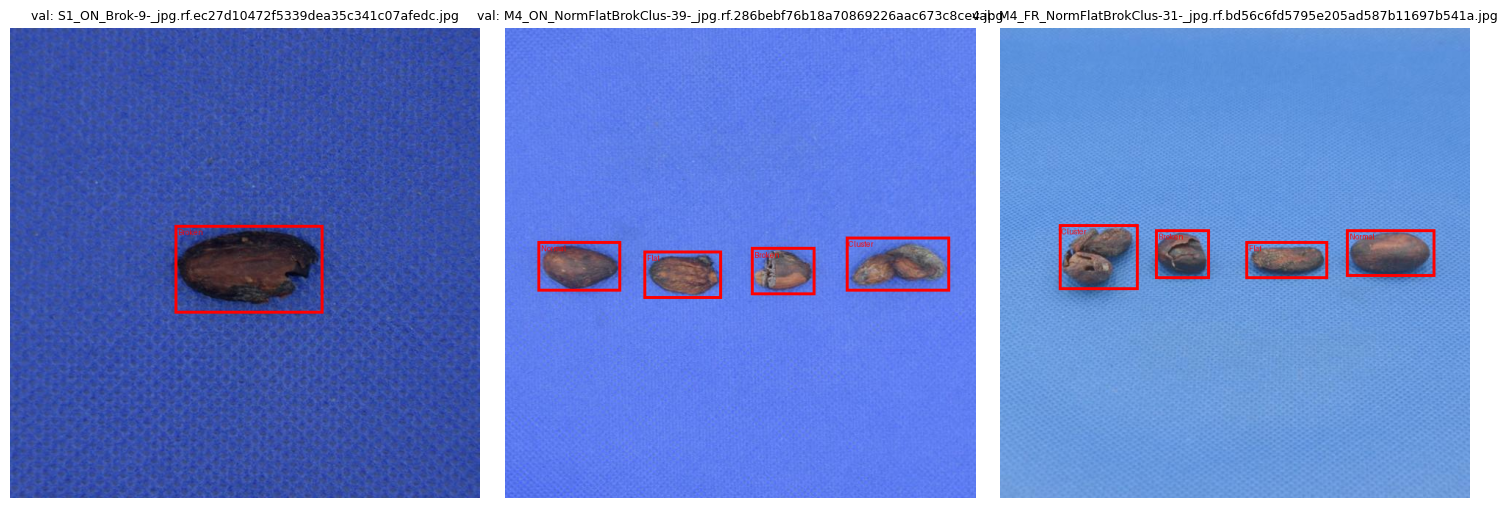

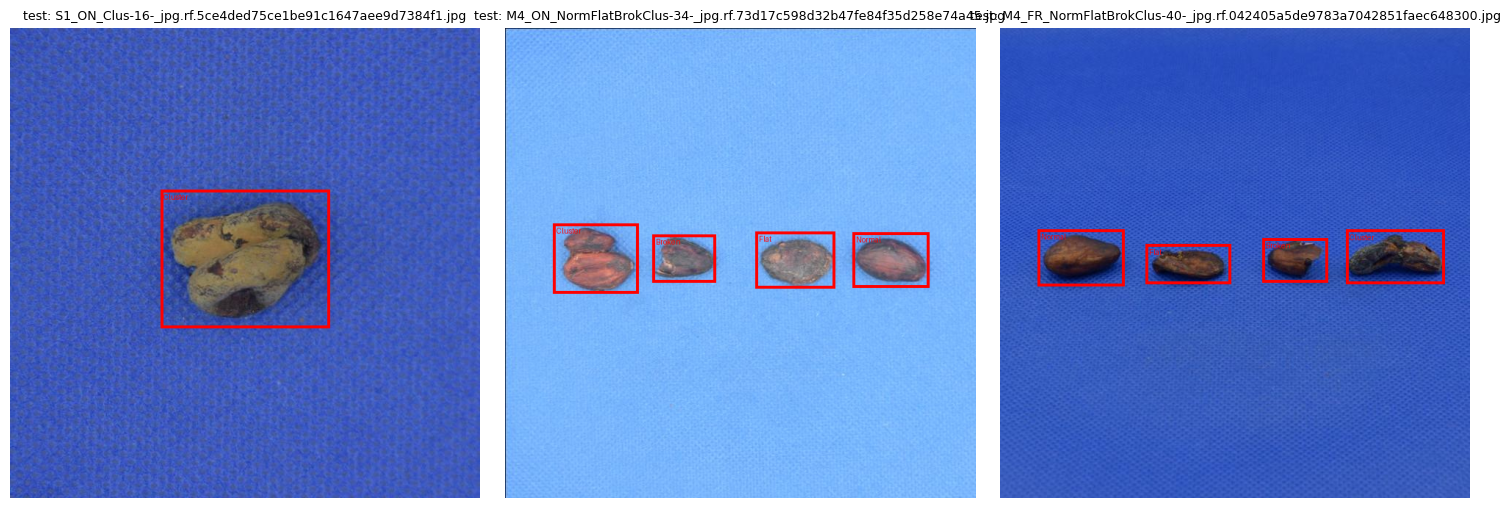

In [ ]:
def draw_sample(split, n=3, seed=SEED):
    rng = random.Random(seed)
    img_dir = YOLO_DIR / "images" / split
    files = sorted(img_dir.glob("*"))
    sample = rng.sample(files, k=min(n, len(files)))
    fig, axes = plt.subplots(1, len(sample), figsize=(5 * len(sample), 5))
    if len(sample) == 1:
        axes = [axes]
    for ax, img_path in zip(axes, sample):
        im = Image.open(img_path).convert("RGB")
        w, h = im.size
        draw = ImageDraw.Draw(im)
        label_path = YOLO_DIR / "labels" / split / (img_path.stem + ".txt")
        if label_path.exists() and label_path.stat().st_size > 0:
            for line in label_path.read_text().strip().splitlines():
                cls, xc, yc, bw, bh = map(float, line.split())
                x1 = (xc - bw / 2) * w
                y1 = (yc - bh / 2) * h
                x2 = (xc + bw / 2) * w
                y2 = (yc + bh / 2) * h
                draw.rectangle([x1, y1, x2, y2], outline="red", width=4)
                draw.text((x1 + 4, y1 + 4), yolo_classes[int(cls)], fill="red")
        ax.imshow(im)
        ax.set_title(f"{split}: {img_path.name}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

for split in ["train", "val", "test"]:
    draw_sample(split, n=3)


## 10. Fixed Experimental Settings

In [ ]:
FIXED_SETTINGS = {
    "random_seed": SEED,
    "train_split_pct": 80,
    "val_split_pct": 10,
    "test_split_pct": 10,
    "input_resolution": 640,
    "epochs": 50,
    "batch_size": 16,
    "confidence_threshold": 0.25,
    "iou_threshold": 0.50,
}

# YOLOv11n-specific hyperparameters. These are technically valid Ultralytics defaults for
# a from-COCO-pretrained nano model and are documented here rather than forced to match
# the other two (architecturally different) models.
YOLO_HYPERPARAMS = {
    "model_variant": "yolo11n.pt",       # nano variant, pretrained on COCO
    "optimizer": "auto",                  # Ultralytics auto-selects SGD/AdamW + lr based on config
    "lr0": 0.01,                          # initial learning rate (Ultralytics default for SGD)
    "lrf": 0.01,                          # final OneCycle LR fraction
    "momentum": 0.937,
    "weight_decay": 0.0005,
    "warmup_epochs": 3.0,
    "box_loss_gain": 7.5,
    "cls_loss_gain": 0.5,
    "dfl_loss_gain": 1.5,
    "hsv_h": 0.015, "hsv_s": 0.7, "hsv_v": 0.4,   # default color augmentation
    "degrees": 0.0, "translate": 0.1, "scale": 0.5, "shear": 0.0,
    "fliplr": 0.5, "flipud": 0.0,
    "mosaic": 1.0, "close_mosaic": 10,   # disable mosaic for the final 10 epochs (Ultralytics default)
    "patience": 0,                        # disabled early stopping -> exactly 50 epochs, for a fair cross-model comparison
}

print("Fixed cross-experiment settings:")
for k, v in FIXED_SETTINGS.items():
    print(f"  {k}: {v}")
print("\nYOLOv11n-specific hyperparameters:")
for k, v in YOLO_HYPERPARAMS.items():
    print(f"  {k}: {v}")


Fixed cross-experiment settings:
  random_seed: 42
  train_split_pct: 80
  val_split_pct: 10
  test_split_pct: 10
  input_resolution: 640
  epochs: 50
  batch_size: 16
  confidence_threshold: 0.25
  iou_threshold: 0.5

YOLOv11n-specific hyperparameters:
  model_variant: yolo11n.pt
  optimizer: auto
  lr0: 0.01
  lrf: 0.01
  momentum: 0.937
  weight_decay: 0.0005
  warmup_epochs: 3.0
  box_loss_gain: 7.5
  cls_loss_gain: 0.5
  dfl_loss_gain: 1.5
  hsv_h: 0.015
  hsv_s: 0.7
  hsv_v: 0.4
  degrees: 0.0
  translate: 0.1
  scale: 0.5
  shear: 0.0
  fliplr: 0.5
  flipud: 0.0
  mosaic: 1.0
  close_mosaic: 10
  patience: 0


## 11. Train YOLOv11n

In [ ]:
from ultralytics import YOLO

set_global_seed(SEED)
model = YOLO(YOLO_HYPERPARAMS["model_variant"])

train_results = model.train(
    data=str(data_yaml_path),
    epochs=FIXED_SETTINGS["epochs"],
    batch=FIXED_SETTINGS["batch_size"],
    imgsz=FIXED_SETTINGS["input_resolution"],
    seed=SEED,
    device=0,
    optimizer=YOLO_HYPERPARAMS["optimizer"],
    lr0=YOLO_HYPERPARAMS["lr0"],
    lrf=YOLO_HYPERPARAMS["lrf"],
    momentum=YOLO_HYPERPARAMS["momentum"],
    weight_decay=YOLO_HYPERPARAMS["weight_decay"],
    warmup_epochs=YOLO_HYPERPARAMS["warmup_epochs"],
    box=YOLO_HYPERPARAMS["box_loss_gain"],
    cls=YOLO_HYPERPARAMS["cls_loss_gain"],
    dfl=YOLO_HYPERPARAMS["dfl_loss_gain"],
    hsv_h=YOLO_HYPERPARAMS["hsv_h"], hsv_s=YOLO_HYPERPARAMS["hsv_s"], hsv_v=YOLO_HYPERPARAMS["hsv_v"],
    degrees=YOLO_HYPERPARAMS["degrees"], translate=YOLO_HYPERPARAMS["translate"],
    scale=YOLO_HYPERPARAMS["scale"], shear=YOLO_HYPERPARAMS["shear"],
    fliplr=YOLO_HYPERPARAMS["fliplr"], flipud=YOLO_HYPERPARAMS["flipud"],
    mosaic=YOLO_HYPERPARAMS["mosaic"], close_mosaic=YOLO_HYPERPARAMS["close_mosaic"],
    patience=YOLO_HYPERPARAMS["patience"],
    project=str(WORK_DIR / "runs"),
    name="yolov11n_cacao",
    exist_ok=True,
    verbose=True,
)

RUN_DIR = Path(train_results.save_dir)
BEST_WEIGHTS = RUN_DIR / "weights" / "best.pt"
print(f"\nTraining complete. Run directory: {RUN_DIR}")
print(f"Best weights: {BEST_WEIGHTS}")


Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cacao_yolov11n/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov11n_cacao, 

### Training Curves

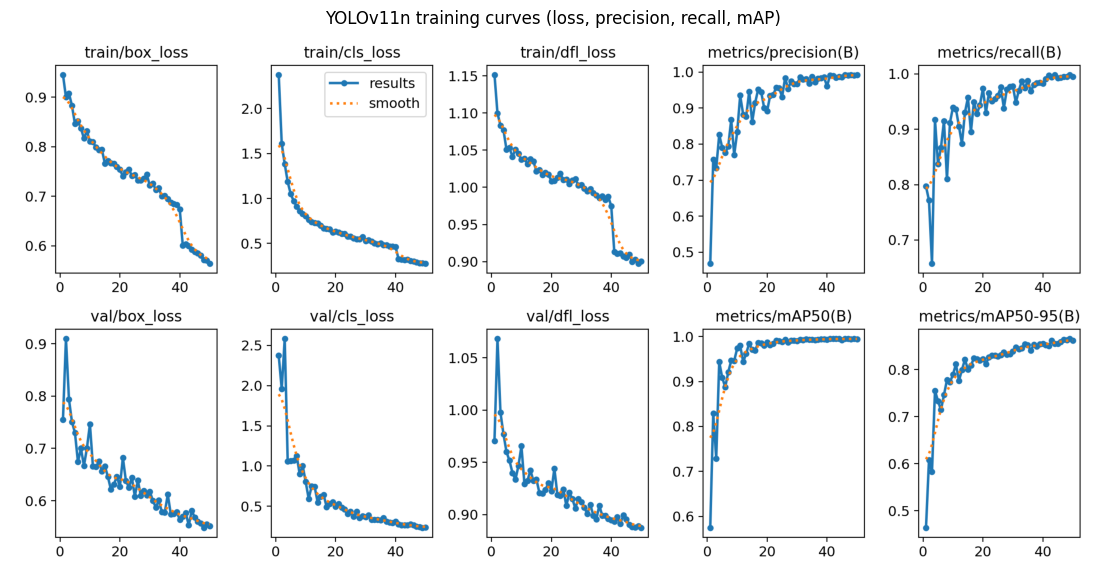

In [ ]:
results_png = RUN_DIR / "results.png"
if results_png.exists():
    img = Image.open(results_png)
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("YOLOv11n training curves (loss, precision, recall, mAP)")
    plt.show()
else:
    print("results.png not found -- check RUN_DIR contents.")


## 12. Evaluation on the Test Set (10% held-out)

Evaluated **only** on the untouched test split, using the fixed confidence (0.25) and IoU (0.50) thresholds.

In [ ]:
best_model = YOLO(str(BEST_WEIGHTS))

test_metrics = best_model.val(
    data=str(data_yaml_path),
    split="test",
    imgsz=FIXED_SETTINGS["input_resolution"],
    conf=FIXED_SETTINGS["confidence_threshold"],
    iou=FIXED_SETTINGS["iou_threshold"],
    device=0,
    project=str(WORK_DIR / "runs"),
    name="yolov11n_cacao_test_eval",
    exist_ok=True,
    verbose=True,
)

precision = float(test_metrics.box.mp)
recall = float(test_metrics.box.mr)
map50 = float(test_metrics.box.map50)
map50_95 = float(test_metrics.box.map)

print("\n=== Detection Accuracy (test set) ===")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"mAP@0.5     : {map50:.4f}")
print(f"mAP@0.5:0.95: {map50_95:.4f}")

per_class_rows = []
for i, name in enumerate(yolo_classes):
    per_class_rows.append({
        "class": name,
        "precision": float(test_metrics.box.p[i]) if len(test_metrics.box.p) > i else None,
        "recall": float(test_metrics.box.r[i]) if len(test_metrics.box.r) > i else None,
        "AP50": float(test_metrics.box.ap50[i]) if len(test_metrics.box.ap50) > i else None,
        "AP50-95": float(test_metrics.box.ap[i]) if len(test_metrics.box.ap) > i else None,
    })
per_class_df = pd.DataFrame(per_class_rows)
display(per_class_df)


Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1719.1±578.1 MB/s, size: 55.3 KB)
val: Scanning /content/cacao_yolov11n/yolo_dataset/labels/test... 240 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 240/240 2.0Kit/s 0.1s
val: New cache created: /content/cacao_yolov11n/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 3.6it/s 4.1s
                   all        240        364      0.995       0.99      0.988       0.86
                Broken         89         89          1          1      0.995      0.879
               Cluster         95         95          1          1      0.995      0.889
                  Flat         88         89          1       0.97      0.985      0.825
                Normal         90         9

,class,precision,recall,AP50,AP50-95
0,Broken,0.999551,1.000000,0.995000,0.878666
1,Cluster,1.000000,1.000000,0.995000,0.889486
2,Flat,1.000000,0.969727,0.984888,0.824857
3,Normal,0.982331,0.989011,0.978626,0.846617


### Confusion Matrix

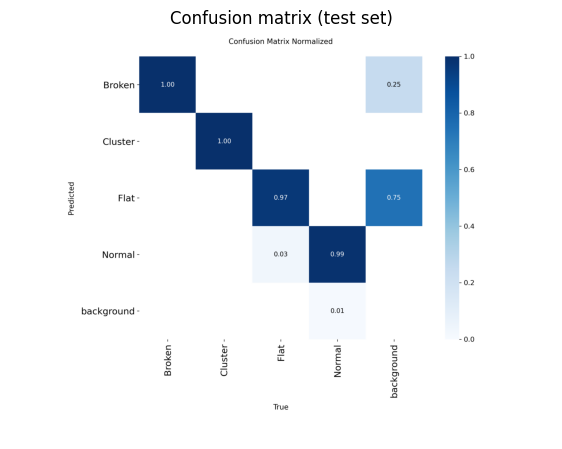

In [ ]:
cm_path = Path(test_metrics.save_dir) / "confusion_matrix_normalized.png"
if not cm_path.exists():
    cm_path = Path(test_metrics.save_dir) / "confusion_matrix.png"
if cm_path.exists():
    img = Image.open(cm_path)
    plt.figure(figsize=(7, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Confusion matrix (test set)")
    plt.show()
else:
    print("Confusion matrix image not found in", test_metrics.save_dir)


## 13. Inference Speed

In [ ]:
test_images = sorted((YOLO_DIR / "images" / "test").glob("*"))
n_warmup = 5
n_timed = len(test_images)

# Warm-up (excluded from timing).
for p in test_images[:n_warmup]:
    _ = best_model.predict(str(p), imgsz=FIXED_SETTINGS["input_resolution"], device=0, verbose=False)

torch.cuda.synchronize()
per_image_ms = []
for p in test_images:
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = best_model.predict(str(p), imgsz=FIXED_SETTINGS["input_resolution"],
                            conf=FIXED_SETTINGS["confidence_threshold"],
                            iou=FIXED_SETTINGS["iou_threshold"],
                            device=0, verbose=False)
    torch.cuda.synchronize()
    per_image_ms.append((time.perf_counter() - t0) * 1000.0)

avg_inference_ms = float(np.mean(per_image_ms))
fps = 1000.0 / avg_inference_ms if avg_inference_ms > 0 else float("nan")

print(f"Images timed          : {n_timed}")
print(f"Average inference time: {avg_inference_ms:.2f} ms/image (end-to-end predict() call, incl. pre/post-processing)")
print(f"Throughput             : {fps:.2f} FPS")

# Cross-check against Ultralytics' own internal speed breakdown captured during val().
print("\nUltralytics internal speed breakdown from the test-set val() run (ms/image):")
for k, v in test_metrics.speed.items():
    print(f"  {k}: {v:.3f} ms")


Images timed          : 240
Average inference time: 15.92 ms/image (end-to-end predict() call, incl. pre/post-processing)
Throughput             : 62.80 FPS

Ultralytics internal speed breakdown from the test-set val() run (ms/image):
  preprocess: 2.507 ms
  inference: 4.875 ms
  loss: 0.001 ms
  postprocess: 1.811 ms


## 14. Computational Efficiency and Model Size

In [ ]:
try:
    n_layers, n_params, n_grad, gflops = best_model.info(verbose=False)
except Exception as e:
    print("model.info() did not return the expected tuple, falling back to manual parameter count:", e)
    n_params = sum(p.numel() for p in best_model.model.parameters())
    n_layers, n_grad, gflops = None, None, None

model_size_mb = os.path.getsize(BEST_WEIGHTS) / (1024 ** 2)

torch.cuda.reset_peak_memory_stats()
_ = best_model.predict(str(test_images[0]), imgsz=FIXED_SETTINGS["input_resolution"], device=0, verbose=False)
peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

print("=== Computational Efficiency & Model Size ===")
print(f"Parameters          : {n_params:,}")
if gflops is not None:
    print(f"GFLOPs (at {FIXED_SETTINGS['input_resolution']}x{FIXED_SETTINGS['input_resolution']}): {gflops:.2f}")
print(f"Model file size      : {model_size_mb:.2f} MB  ({BEST_WEIGHTS.name})")
print(f"Peak GPU memory (inference, single image): {peak_mem_mb:.1f} MB")


model.info() did not return the expected tuple, falling back to manual parameter count: cannot unpack non-iterable NoneType object
=== Computational Efficiency & Model Size ===
Parameters          : 2,582,932
Model file size      : 5.22 MB  (best.pt)
Peak GPU memory (inference, single image): 139.8 MB


## 15. Robustness Evaluation

The **test set only** is perturbed under four controlled conditions applied one at a time: brightness, contrast, additive Gaussian noise, and small-angle rotation. Bounding boxes are recomputed exactly for the rotation case (axis-aligned box of the rotated corners); brightness/contrast/noise do not move object locations, so boxes are copied unchanged. The **same trained model and the same conf/IoU thresholds** are then evaluated on each perturbed copy, following an identical procedure so all three experiments can be compared on the same robustness protocol.

In [ ]:
ROBUST_DIR = WORK_DIR / "robustness_sets"
if ROBUST_DIR.exists():
    shutil.rmtree(ROBUST_DIR)
ROBUST_DIR.mkdir(parents=True)

ROTATION_DEGREES = 10  # small orientation change

def rotate_bbox(xc, yc, w, h, img_w, img_h, angle_deg):
    # Rotate a normalized YOLO box about the image center and return a new axis-aligned box.
    cx, cy = img_w / 2.0, img_h / 2.0
    x1, y1 = (xc - w / 2) * img_w, (yc - h / 2) * img_h
    x2, y2 = (xc + w / 2) * img_w, (yc + h / 2) * img_h
    corners = [(x1, y1), (x2, y1), (x2, y2), (x1, y2)]
    theta = math.radians(-angle_deg)  # PIL rotates counter-clockwise for positive angle
    rc = []
    for (x, y) in corners:
        rx = cx + (x - cx) * math.cos(theta) - (y - cy) * math.sin(theta)
        ry = cy + (x - cx) * math.sin(theta) + (y - cy) * math.cos(theta)
        rc.append((rx, ry))
    xs = [p[0] for p in rc]; ys = [p[1] for p in rc]
    nx1, nx2 = max(0, min(xs)), min(img_w, max(xs))
    ny1, ny2 = max(0, min(ys)), min(img_h, max(ys))
    nxc = ((nx1 + nx2) / 2) / img_w
    nyc = ((ny1 + ny2) / 2) / img_h
    nw = (nx2 - nx1) / img_w
    nh = (ny2 - ny1) / img_h
    return nxc, nyc, nw, nh

def build_perturbed_set(name, transform_fn, rotate=False):
    img_out = ROBUST_DIR / name / "images" / "test"
    lbl_out = ROBUST_DIR / name / "labels" / "test"
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    src_img_dir = YOLO_DIR / "images" / "test"
    src_lbl_dir = YOLO_DIR / "labels" / "test"

    for img_path in sorted(src_img_dir.glob("*")):
        im = Image.open(img_path).convert("RGB")
        w, h = im.size
        new_im = transform_fn(im)
        new_im.save(img_out / img_path.name)

        src_label = src_lbl_dir / (img_path.stem + ".txt")
        lines_out = []
        if src_label.exists() and src_label.stat().st_size > 0:
            for line in src_label.read_text().strip().splitlines():
                cls, xc, yc, bw, bh = line.split()
                cls = int(cls); xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
                if rotate:
                    xc, yc, bw, bh = rotate_bbox(xc, yc, bw, bh, w, h, ROTATION_DEGREES)
                lines_out.append(f"{cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")
        (lbl_out / (img_path.stem + ".txt")).write_text("\n".join(lines_out))

    yaml_path = ROBUST_DIR / name / "data.yaml"
    with open(yaml_path, "w") as f:
        f.write(f"path: {ROBUST_DIR / name}\n")
        f.write("train: images/test\n")   # unused, val()-only dataset
        f.write("val: images/test\n")
        f.write("test: images/test\n")
        f.write(f"nc: {len(yolo_classes)}\n")
        f.write("names: " + json.dumps(yolo_classes) + "\n")
    return yaml_path

perturbations = {
    "brightness_down": lambda im: ImageEnhance.Brightness(im).enhance(0.6),
    "brightness_up":   lambda im: ImageEnhance.Brightness(im).enhance(1.4),
    "contrast_down":   lambda im: ImageEnhance.Contrast(im).enhance(0.6),
    "contrast_up":     lambda im: ImageEnhance.Contrast(im).enhance(1.4),
    "gaussian_noise":  lambda im: Image.fromarray(
        np.clip(np.array(im).astype(np.float32) + np.random.default_rng(SEED).normal(0, 15, np.array(im).shape),
                0, 255).astype(np.uint8)),
    "rotation_10deg":  lambda im: im.rotate(ROTATION_DEGREES, resample=Image.BILINEAR, expand=False, fillcolor=(114, 114, 114)),
}
rotate_flags = {k: (k == "rotation_10deg") for k in perturbations}

perturbed_yaml_paths = {}
for name, fn in perturbations.items():
    perturbed_yaml_paths[name] = build_perturbed_set(name, fn, rotate=rotate_flags[name])
    print(f"Built perturbed test set: {name}")


Built perturbed test set: brightness_down
Built perturbed test set: brightness_up
Built perturbed test set: contrast_down
Built perturbed test set: contrast_up
Built perturbed test set: gaussian_noise
Built perturbed test set: rotation_10deg


In [ ]:
robustness_rows = []
for name, yaml_path in perturbed_yaml_paths.items():
    m = best_model.val(
        data=str(yaml_path),
        split="test",
        imgsz=FIXED_SETTINGS["input_resolution"],
        conf=FIXED_SETTINGS["confidence_threshold"],
        iou=FIXED_SETTINGS["iou_threshold"],
        device=0,
        project=str(WORK_DIR / "runs"),
        name=f"yolov11n_robust_{name}",
        exist_ok=True,
        verbose=False,
    )
    robustness_rows.append({
        "perturbation": name,
        "precision": float(m.box.mp),
        "recall": float(m.box.mr),
        "mAP50": float(m.box.map50),
        "mAP50_95": float(m.box.map),
    })

robustness_rows.insert(0, {
    "perturbation": "baseline (clean test set)",
    "precision": precision, "recall": recall, "mAP50": map50, "mAP50_95": map50_95,
})
robustness_df = pd.DataFrame(robustness_rows)
display(robustness_df)


Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1011.8±251.2 MB/s, size: 45.4 KB)
val: Scanning /content/cacao_yolov11n/robustness_sets/brightness_down/labels/test... 240 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 240/240 1.9Kit/s 0.1s
val: New cache created: /content/cacao_yolov11n/robustness_sets/brightness_down/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.7it/s 5.5s
                   all        240        364      0.991      0.983      0.985      0.855
Speed: 5.0ms preprocess, 4.8ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to /content/cacao_yolov11n/runs/yolov11n_robust_brightness_down
Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1755.6±509.1 MB/s, size: 58.4 KB)
val: Scanning /content/caca

,perturbation,precision,recall,mAP50,mAP50_95
0,baseline (clean test set),0.995470,0.989685,0.988379,0.859906
1,brightness_down,0.990892,0.983176,0.985444,0.854582
2,brightness_up,0.994056,0.994444,0.987885,0.855155
3,contrast_down,0.983556,0.990029,0.985050,0.856350
4,contrast_up,0.995333,0.994444,0.988379,0.859382
5,gaussian_noise,0.986048,0.978517,0.979803,0.841730
6,rotation_10deg,0.985958,0.962552,0.980853,0.466117


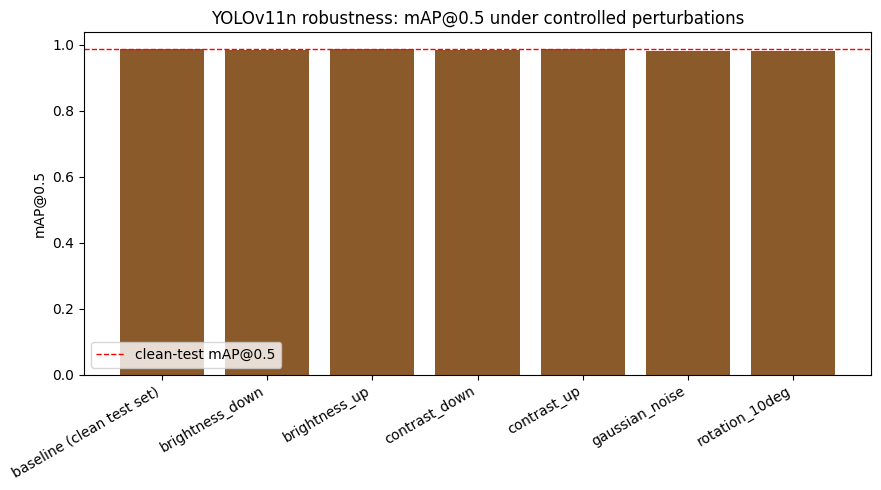

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(robustness_df["perturbation"], robustness_df["mAP50"], color="#8a5a2b")
ax.axhline(map50, color="red", linestyle="--", linewidth=1, label="clean-test mAP@0.5")
ax.set_ylabel("mAP@0.5")
ax.set_title("YOLOv11n robustness: mAP@0.5 under controlled perturbations")
plt.xticks(rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.show()


## 16. Reproducibility Record

In [ ]:
import sklearn
reproducibility_record = {
    "random_seed": SEED,
    "dataset": {
        "source_zip": DATASET_ZIP,
        "roboflow_version": 12,
        "total_images": len(pool),
        "split_manifest": str(manifest_path) if EXTERNAL_SPLIT_MANIFEST is None else EXTERNAL_SPLIT_MANIFEST,
        "split_sizes": dict(split_counts),
        "classes": yolo_classes,
    },
    "model": {
        "name": "YOLOv11n",
        "weights_pretrained_from": YOLO_HYPERPARAMS["model_variant"],
        "best_weights_path": str(BEST_WEIGHTS),
    },
    "software_versions": {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "cuda": torch.version.cuda,
        "ultralytics": ultralytics.__version__,
        "scikit_learn": sklearn.__version__,
    },
    "hardware": {
        "gpu_name": gpu_name,
    },
    "fixed_settings": FIXED_SETTINGS,
    "yolo_hyperparameters": YOLO_HYPERPARAMS,
}

repro_path = WORK_DIR / "reproducibility_record.json"
with open(repro_path, "w") as f:
    json.dump(reproducibility_record, f, indent=2, default=str)

print(json.dumps(reproducibility_record, indent=2, default=str))


{
  "random_seed": 42,
  "dataset": {
    "source_zip": "Cacao Bean Detection_Trial 01.v5-trial4_2400.coco.zip",
    "roboflow_version": 12,
    "total_images": 2400,
    "split_manifest": "/content/cacao_yolov11n/dataset_split_seed42.json",
    "split_sizes": {
      "train": 1920,
      "val": 240,
      "test": 240
    },
    "classes": [
      "Broken",
      "Cluster",
      "Flat",
      "Normal"
    ]
  },
  "model": {
    "name": "YOLOv11n",
    "weights_pretrained_from": "yolo11n.pt",
    "best_weights_path": "/content/cacao_yolov11n/runs/yolov11n_cacao/weights/best.pt"
  },
  "software_versions": {
    "python": "3.13.15",
    "torch": "2.11.0+cu128",
    "cuda": "12.8",
    "ultralytics": "8.4.138",
    "scikit_learn": "1.6.1"
  },
  "hardware": {
    "gpu_name": "Tesla T4"
  },
  "fixed_settings": {
    "random_seed": 42,
    "train_split_pct": 80,
    "val_split_pct": 10,
    "test_split_pct": 10,
    "input_resolution": 640,
    "epochs": 50,
    "batch_size": 16,
    "co

## 17. Final Results Table — Five Evaluation Criteria

In [ ]:
final_rows = [
    ("1. Detection Accuracy", "Precision (test set)", f"{precision:.4f}"),
    ("1. Detection Accuracy", "Recall (test set)", f"{recall:.4f}"),
    ("1. Detection Accuracy", "mAP@0.5", f"{map50:.4f}"),
    ("1. Detection Accuracy", "mAP@0.5:0.95", f"{map50_95:.4f}"),
    ("2. Inference Speed", "Avg. inference time / image", f"{avg_inference_ms:.2f} ms"),
    ("2. Inference Speed", "Throughput", f"{fps:.2f} FPS"),
    ("3. Computational Efficiency", "Parameters", f"{n_params:,}"),
    ("3. Computational Efficiency", "GFLOPs", f"{gflops:.2f}" if gflops is not None else "n/a"),
    ("3. Computational Efficiency", "Peak GPU memory (inference)", f"{peak_mem_mb:.1f} MB"),
    ("4. Model Size", "File size", f"{model_size_mb:.2f} MB"),
    ("4. Model Size", "Parameters", f"{n_params:,}"),
    ("5. Robustness", "Worst-case mAP@0.5 (any perturbation)",
     f"{robustness_df[robustness_df['perturbation'] != 'baseline (clean test set)']['mAP50'].min():.4f}"),
    ("5. Robustness", "Mean mAP@0.5 across all perturbations",
     f"{robustness_df[robustness_df['perturbation'] != 'baseline (clean test set)']['mAP50'].mean():.4f}"),
]
final_df = pd.DataFrame(final_rows, columns=["Criterion", "Indicator", "Value"])
final_csv_path = WORK_DIR / "yolov11n_final_results.csv"
final_df.to_csv(final_csv_path, index=False)

pd.set_option("display.max_colwidth", None)
display(final_df)
print(f"\nSaved to: {final_csv_path}")
print("All values above were measured directly in this notebook run; none were fabricated or estimated.")


,Criterion,Indicator,Value
0,1. Detection Accuracy,Precision (test set),0.9955
1,1. Detection Accuracy,Recall (test set),0.9897
2,1. Detection Accuracy,mAP@0.5,0.9884
3,1. Detection Accuracy,mAP@0.5:0.95,0.8599
4,2. Inference Speed,Avg. inference time / image,15.92 ms
5,2. Inference Speed,Throughput,62.80 FPS
6,3. Computational Efficiency,Parameters,"2,582,932"
7,3. Computational Efficiency,GFLOPs,n/a
8,3. Computational Efficiency,Peak GPU memory (inference),139.8 MB
9,4. Model Size,File size,5.22 MB



Saved to: /content/cacao_yolov11n/yolov11n_final_results.csv
All values above were measured directly in this notebook run; none were fabricated or estimated.
